# Sentiment Analysis using Machine Learning

## Objective

The objective of this notebook is to build a machine learning model that classifies customer reviews into Positive or Negative sentiments.

The notebook includes:

- Data preprocessing
- Text cleaning
- Feature extraction using TF-IDF
- Model training
- Model evaluation
- Prediction on new reviews

In [16]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [17]:
reviews = pd.read_csv("processed/reviews_clean.csv")

reviews.head()

,s.no,helpfulVoteCount,images/0,images/1,images/2,images/3,images/4,images/5,images/6,images/7,...,reviewID,reviewMetadata,reviewPosition,reviewText,reviewTitle,reviewURL,verifiedPurchase,videos/0,cleaned_review_text,sentiment_score
0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,R2AUQFPJY5ERCZ,"Reviewed in the United States on March 6, 2025",1,‚úçÔ∏è The COOFANDY Men's Polo Shirt is a fant...,Stylish and Lightweight COOFANDY Polo Shirt,https://www.amazon.com/review/R2AUQFPJY5ERCZ,False,NaN,coofandy men polo shirt fantastic blend style ...,0.292024
1,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,R1YNLJ0QFLB1VT,"Reviewed in the United States on March 7, 2025",1,I love these. They look good. They fit well. T...,New favorite shirts,https://www.amazon.com/review/R1YNLJ0QFLB1VT,False,NaN,love look good fit well comfortable breathable...,0.560000
2,2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,R11LIYW9RMDK9R,"Reviewed in the United States on February 27, ...",2,My expectations were low -- how good could shi...,Incredibly Good Deal,https://www.amazon.com/review/R11LIYW9RMDK9R,False,NaN,expectation low good could shirt sell one mist...,0.192321
3,3,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,R3K9X391DJNTPZ,"Reviewed in the United States on February 26, ...",3,This 3-pack of multi-color shirts is really a ...,Higher quality & breathable 3-pack shirt set t...,https://www.amazon.com/review/R3K9X391DJNTPZ,False,NaN,pack multicolor shirt really brainer wear type...,0.307949
4,4,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,RP17IW9ZKENDZ,"Reviewed in the United States on February 20, ...",4,With these three polo shirts I was very satisf...,Pocket Polos Looks Good,https://www.amazon.com/review/RP17IW9ZKENDZ,False,NaN,three polo shirt satisfied quality material go...,0.250000


In [18]:
print("Shape :", reviews.shape)

reviews.info()

Shape : (6327, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6327 entries, 0 to 6326
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   s.no                 6327 non-null   int64  
 1   helpfulVoteCount     6327 non-null   int64  
 2   images/0             516 non-null    object 
 3   images/1             212 non-null    object 
 4   images/2             98 non-null     object 
 5   images/3             49 non-null     object 
 6   images/4             26 non-null     object 
 7   images/5             14 non-null     object 
 8   images/6             7 non-null      object 
 9   images/7             5 non-null      object 
 10  productASIN          6327 non-null   object 
 11  productVariant       5836 non-null   object 
 12  rating               6320 non-null   float64
 13  reviewID             6327 non-null   object 
 14  reviewMetadata       6296 non-null   object 
 15  reviewPosition     

In [19]:
reviews.columns

Index(['s.no', 'helpfulVoteCount', 'images/0', 'images/1', 'images/2',
       'images/3', 'images/4', 'images/5', 'images/6', 'images/7',
       'productASIN', 'productVariant', 'rating', 'reviewID', 'reviewMetadata',
       'reviewPosition', 'reviewText', 'reviewTitle', 'reviewURL',
       'verifiedPurchase', 'videos/0', 'cleaned_review_text',
       'sentiment_score'],
      dtype='object')

In [20]:
sentiment_df = reviews[
    [
        "cleaned_review_text",
        "rating"
    ]
].copy()

sentiment_df.head()

,cleaned_review_text,rating
0,coofandy men polo shirt fantastic blend style ...,5.0
1,love look good fit well comfortable breathable...,5.0
2,expectation low good could shirt sell one mist...,4.0
3,pack multicolor shirt really brainer wear type...,5.0
4,three polo shirt satisfied quality material go...,5.0


In [21]:
# Remove missing review text
sentiment_df = sentiment_df.dropna(
    subset=["cleaned_review_text"]
)

# Convert to string
sentiment_df["cleaned_review_text"] = (
    sentiment_df["cleaned_review_text"]
    .astype(str)
)

# Remove empty reviews
sentiment_df = sentiment_df[
    sentiment_df["cleaned_review_text"].str.strip() != ""
]

# Remove neutral reviews
sentiment_df = sentiment_df[
    sentiment_df["rating"] != 3
]

# Create sentiment labels
sentiment_df["sentiment"] = sentiment_df["rating"].apply(
    lambda x: 1 if x >= 4 else 0
)

sentiment_df.head()

,cleaned_review_text,rating,sentiment
0,coofandy men polo shirt fantastic blend style ...,5.0,1
1,love look good fit well comfortable breathable...,5.0,1
2,expectation low good could shirt sell one mist...,4.0,1
3,pack multicolor shirt really brainer wear type...,5.0,1
4,three polo shirt satisfied quality material go...,5.0,1


In [22]:
print("Missing Reviews :")

print(
    sentiment_df["cleaned_review_text"].isnull().sum()
)

print("\nClass Distribution")

print(
    sentiment_df["sentiment"].value_counts()
)

Missing Reviews :
0

Class Distribution
sentiment
1    5663
0     212
Name: count, dtype: int64


In [23]:
X = sentiment_df["cleaned_review_text"]

y = sentiment_df["sentiment"]

In [24]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42

)

In [25]:
print("Training Samples :", len(X_train))

print("Testing Samples :", len(X_test))

Training Samples : 4700
Testing Samples : 1175


In [26]:
tfidf = TfidfVectorizer(

    stop_words="english",

    max_features=5000

)

In [27]:
X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

In [28]:
print(X_train_tfidf.shape)

(4700, 5000)


In [29]:
model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train_tfidf,
    y_train
)

print("Model Trained Successfully!")

Model Trained Successfully!


In [30]:
y_pred = model.predict(
    X_test_tfidf
)

In [31]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy :", round(accuracy*100,2), "%")

Accuracy : 96.77 %


In [32]:
print(

    classification_report(

        y_test,

        y_pred

    )

)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        38
           1       0.97      1.00      0.98      1137

    accuracy                           0.97      1175
   macro avg       0.48      0.50      0.49      1175
weighted avg       0.94      0.97      0.95      1175



C:\Users\Aman Tiwari\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Aman Tiwari\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Aman Tiwari\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


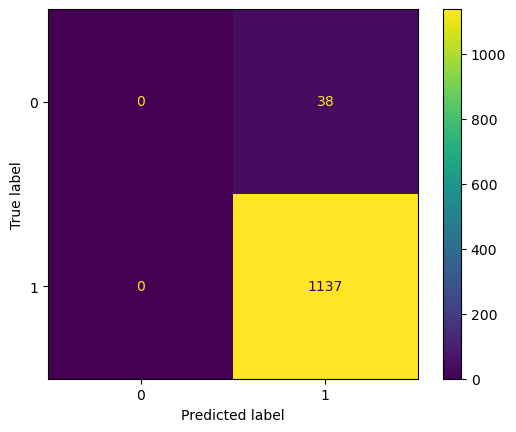

In [33]:
cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.show()

In [34]:
sample_reviews = [

    "Excellent quality product. I loved it.",

    "Worst product ever. Waste of money.",

    "Amazing build quality and fast delivery.",

    "Very disappointed with this purchase."

]

In [35]:
sample_vector = tfidf.transform(
    sample_reviews
)

predictions = model.predict(
    sample_vector
)

for review, prediction in zip(sample_reviews, predictions):

    sentiment = "Positive" if prediction == 1 else "Negative"

    print("-----------------------------------")

    print("Review :", review)

    print("Prediction :", sentiment)

-----------------------------------
Review : Excellent quality product. I loved it.
Prediction : Positive
-----------------------------------
Review : Worst product ever. Waste of money.
Prediction : Negative
-----------------------------------
Review : Amazing build quality and fast delivery.
Prediction : Positive
-----------------------------------
Review : Very disappointed with this purchase.
Prediction : Positive


In [36]:
import pickle
import os

os.makedirs("models", exist_ok=True)

In [37]:
# Save Logistic Regression model
with open("models/sentiment_model.pkl", "wb") as f:
    pickle.dump(model, f)

# Save TF-IDF Vectorizer
with open("models/sentiment_tfidf.pkl", "wb") as f:
    pickle.dump(tfidf, f)

print("Sentiment model saved successfully!")

Sentiment model saved successfully!


## Conclusion

A Logistic Regression model was successfully trained to classify customer reviews into Positive and Negative sentiments.

The model uses TF-IDF vectorization to convert textual reviews into numerical features and demonstrates how Natural Language Processing (NLP) techniques can be applied to analyze customer opinions.

This sentiment analysis model can be integrated into the e-commerce recommendation system to provide additional insights about products.